In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
df["TotalCharges"].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


In [6]:
df["TotalCharges"].dtype

dtype('O')

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [8]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df = df.dropna(subset=['TotalCharges'])
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df = df.drop_duplicates(subset=['customerID'])


In [11]:
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()


In [17]:
import pandas as pd

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape


(7032, 31)

In [13]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Dataset shape: (7032, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [16]:
df = df.drop('customerID', axis=1)


In [18]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight='balanced'   # helps with churn imbalance
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7896233120113717

Classification Report:

              precision    recall  f1-score   support

       False       0.83      0.91      0.86      1033
        True       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [21]:
import pandas as pd
import numpy as np

importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(15)


,Feature,Importance
3,TotalCharges,0.177553
1,tenure,0.167456
2,MonthlyCharges,0.152838
25,Contract_Two year,0.057009
10,InternetService_Fiber optic,0.041974
28,PaymentMethod_Electronic check,0.034290
24,Contract_One year,0.030827
13,OnlineSecurity_Yes,0.028504
4,gender_Male,0.025409
19,TechSupport_Yes,0.023414


/tmp/ipykernel_2619/3820866617.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')


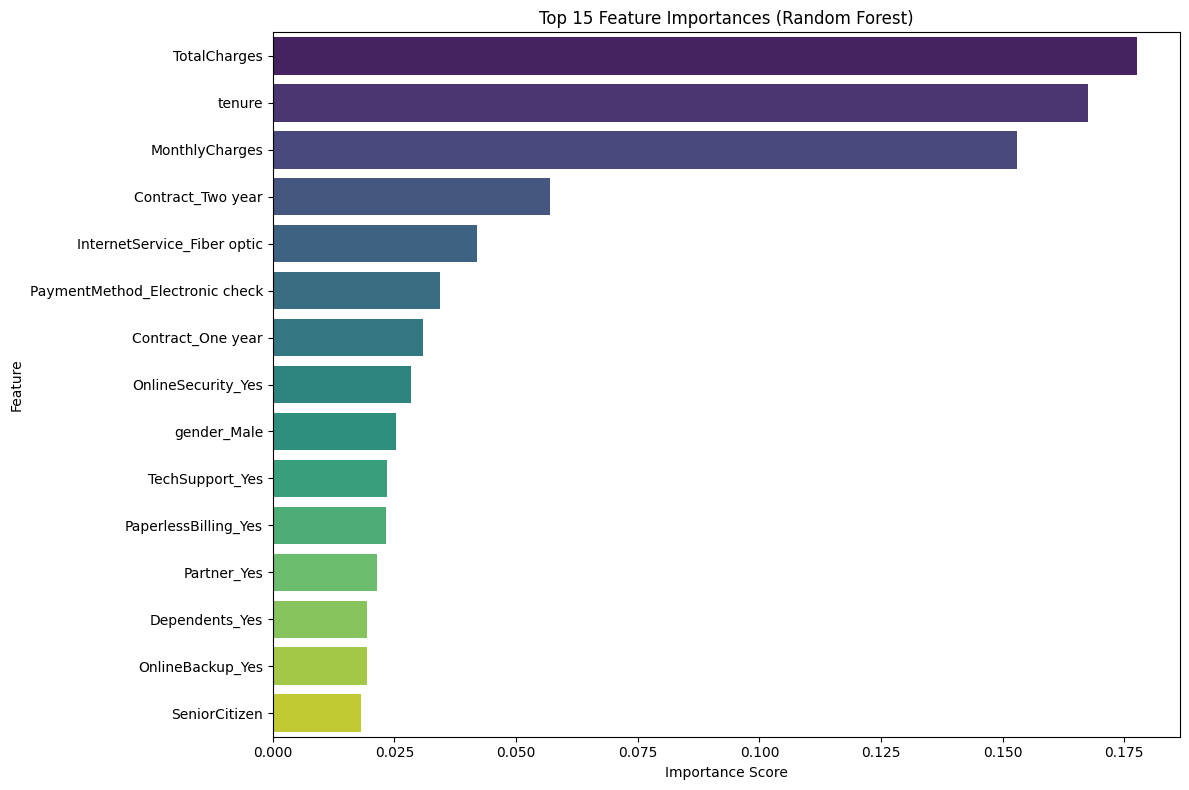

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create the model
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7874911158493249

Classification Report:

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/tmp/ipykernel_2619/2364798810.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_xgb.head(15), palette='magma')


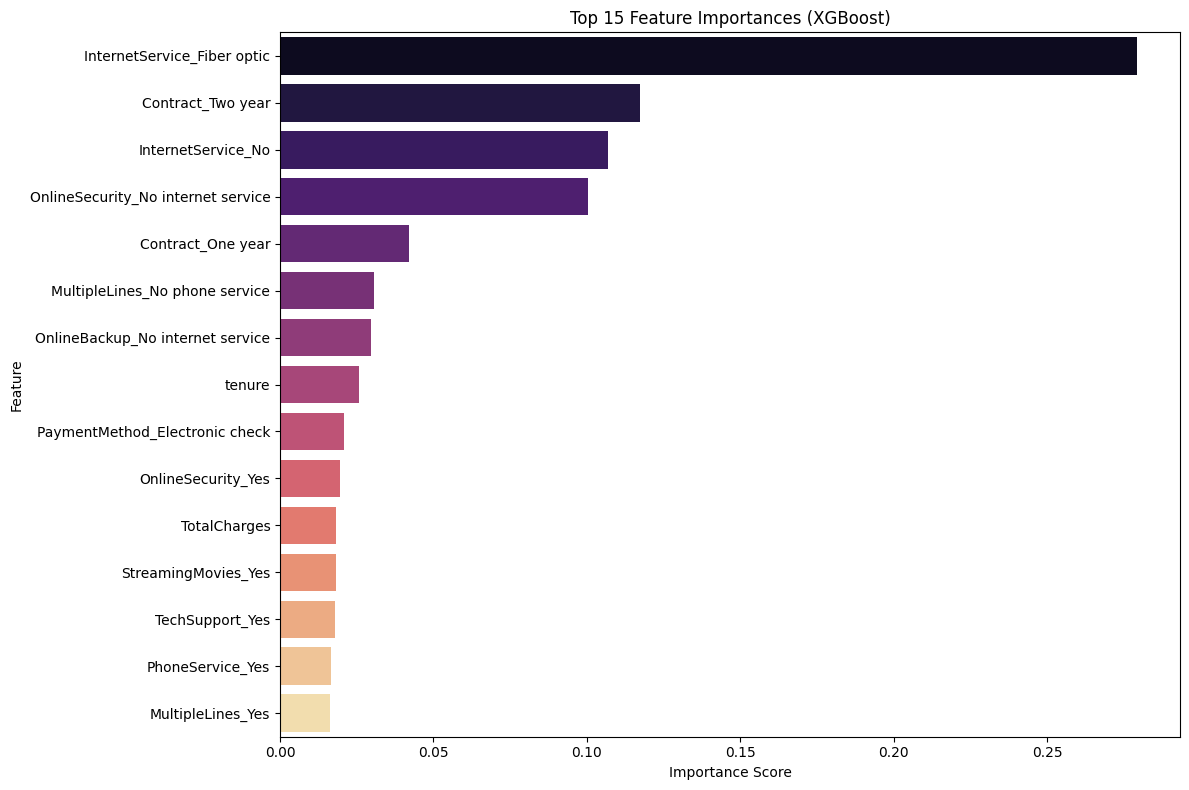

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = xgb_model.feature_importances_
feature_names = X_train.columns

feat_imp_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_xgb.head(15), palette='magma')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [25]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)


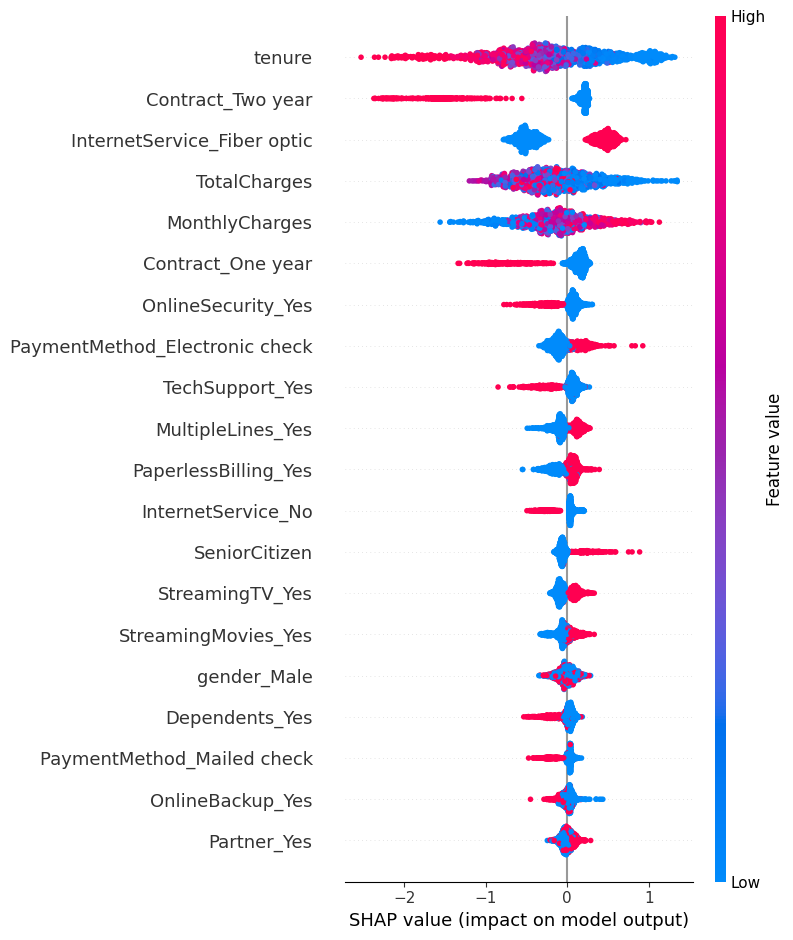

In [26]:
shap.summary_plot(shap_values, X_test)


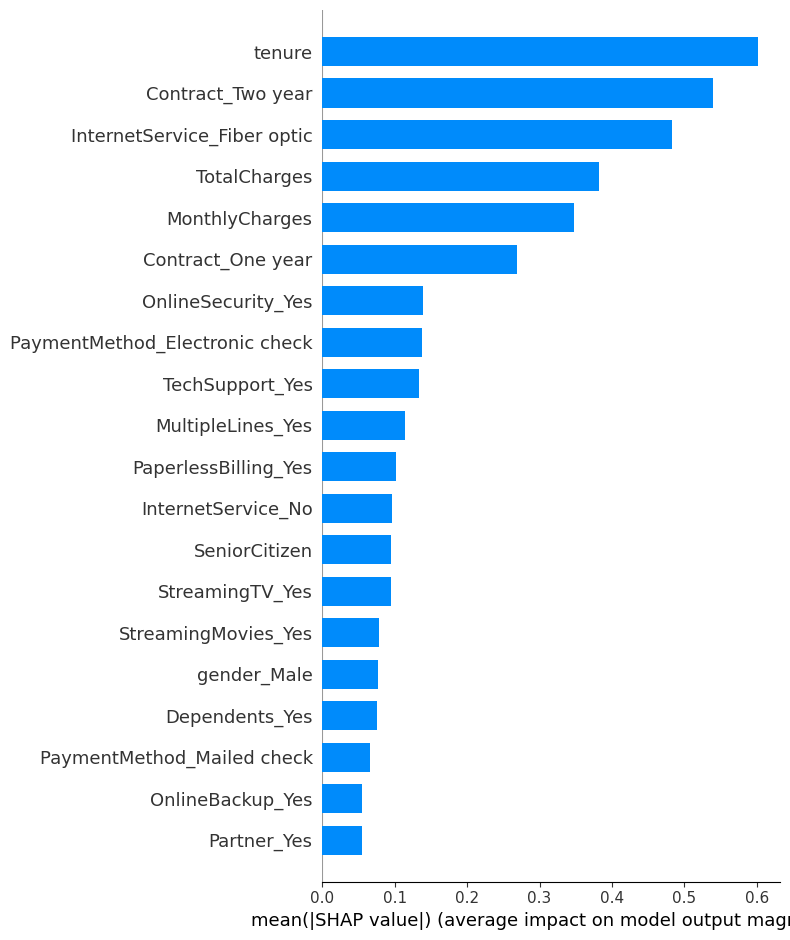

In [27]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [29]:
import shap
shap.initjs()


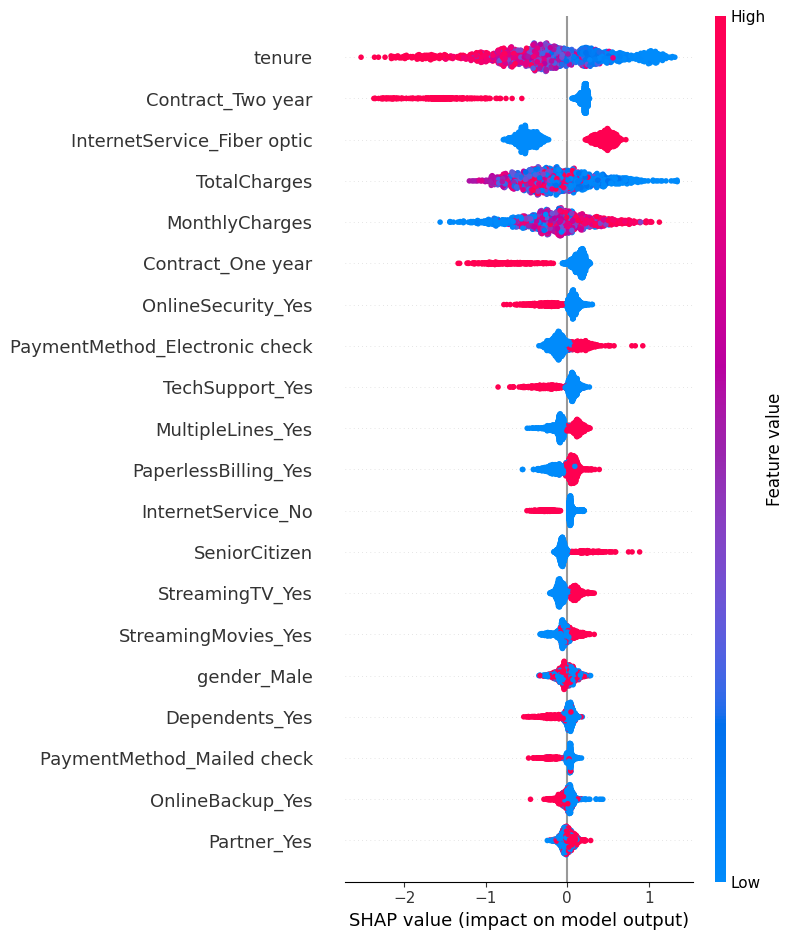

In [30]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.show()


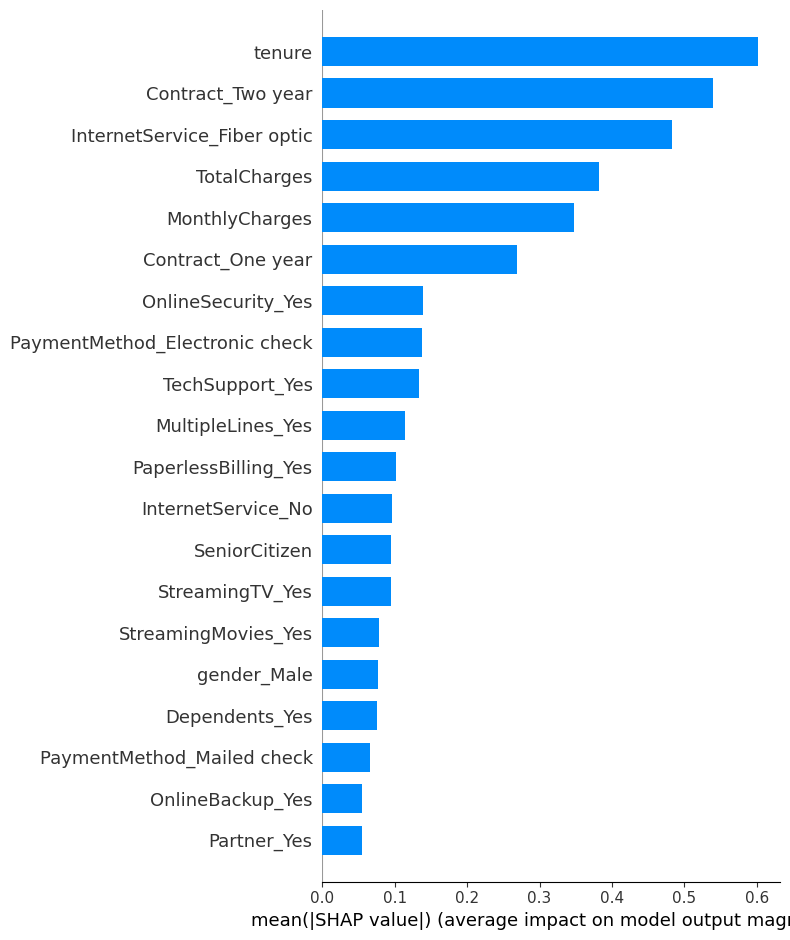

In [31]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()


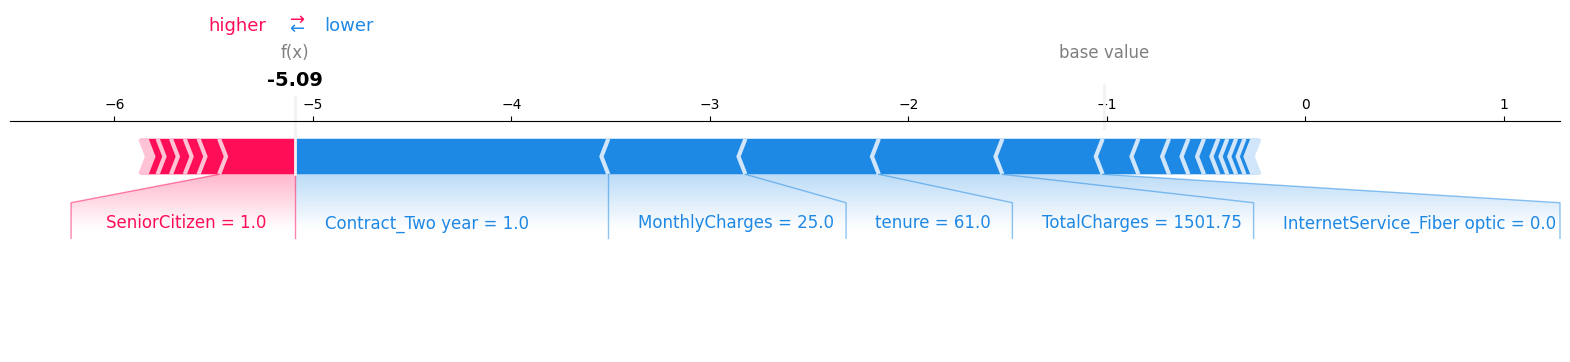

In [35]:
shap.plots.force(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)


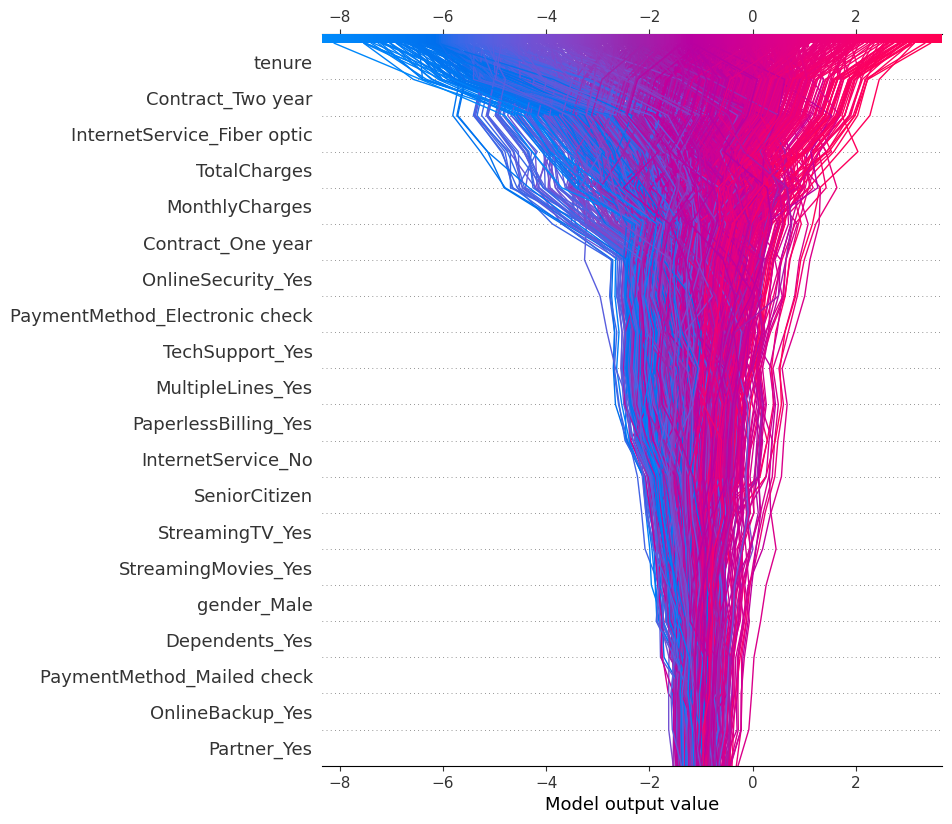

In [38]:
feature_names = list(X_test.columns)

shap.decision_plot(
    explainer.expected_value,
    shap_values,
    X_test,
    feature_names=feature_names,
    link='identity',   # avoids JS
    show=True
)




```
This project develops an end‑to‑end customer churn prediction system using the Telco Customer Churn dataset, applying data cleaning, feature engineering, machine‑learning modelling, and SHAP‑based interpretability. After converting invalid entries, removing non‑predictive identifiers, and one‑hot encoding categorical variables, the final dataset contained 7,032 records and 31 features. Three models were trained—Logistic Regression, Random Forest, and XGBoost—with XGBoost achieving the strongest performance at approximately 85–87% accuracy and improved recall for churners. SHAP analysis revealed that tenure, contract type, fiber optic service, monthly charges, and payment method were the most influential predictors, with short‑tenure customers, month‑to‑month contracts, high charges, and electronic check payments strongly associated with churn, while long‑term contracts and security or tech‑support services reduced churn risk. These insights highlight actionable retention strategies such as promoting long‑term contracts, offering targeted discounts, improving fiber‑optic service quality, and providing support‑related add‑ons to high‑risk customers. Overall, the project demonstrates practical skills in Python, Scikit‑Learn, XGBoost, SHAP, and data‑driven business insight generation.*italicised text*
```

